# STAT 301 Project: Predicting Airbnb Prices in European Cities

Group 16:

In [1]:
# Package Loading
library(tidyverse)
library(ggplot2)
library(ggmap)
library(tidymodels)
library(MASS)
library(glmnet)
library(caret)
library(lmtest)
library(patchwork)
library(janitor)
library(broom)
library(car)
library(Metrics)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.
── Attaching packages ────────────────────────────────────── tidymodels 1.3.0 ──

✔ broom        1.0.8     ✔ rsample      1.3.1
✔ dials        1.4.1     ✔ tune         1.3.0
✔

In [2]:
### Make sure the select function is not masked by MASS
select <- dplyr::select

## 1. Introduction

In this report we will...

In section 2 we perform EDA, ..., section 3 contains a discussion of our ...

## 2. Methods & Results

### 2.1 Exploratory Data Analysis

In [3]:
# Main developer: Nathan Zhang
# Loading the data and select the relevant columns
airbnb_data <- read_csv("https://raw.githubusercontent.com/NathanPalaiologos/STAT-301-Project/main/data/airbnb_europe_data.csv") |>
    filter(city %in% c("budapest", "london", "rome")) |>
    glimpse()

Rows: 51707 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (2): room_type, city
dbl (15): realSum, person_capacity, multi, biz, cleanliness_rating, guest_sa...
lgl  (4): room_shared, room_private, host_is_superhost, weekend

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 23,042
Columns: 21
$ realSum                    <dbl> 238.99046, 300.79428, 162.38191, 118.43775,…
$ room_type                  <chr> "Entire home/apt", "Entire home/apt", "Enti…
$ room_shared                <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, F…
$ room_private               <lgl> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, F…
$ person_capacity            <dbl> 6, 6, 4, 2, 4, 4, 4, 4, 6, 4, 3, 4, 5, 6, 4…
$ host_is_superhost          <lgl> TRUE, FALSE, TRUE, FALSE, TRUE, FALSE, FALS…
$ multi                      <dbl> 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0…
$ biz                        <dbl> 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1…
$ cleanliness_rating         <dbl> 10, 9, 10, 9, 10, 9, 6, 9, 10, 10, 10, 10, …
$ guest_satisfaction_overall <dbl> 99, 98, 98, 92, 99, 91, 80, 92, 88, 96, 100…
$ bedrooms                   <dbl> 1, 2, 1, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 0…
$ dist                       <dbl> 0.3593550, 0.9294272, 2.4508403, 1.5594494,…
$ metro_dist   

A summary of the full variables in the dataset is provided below:

| Variable                   | Type        | Meaning                                                                    |
|----------------------------|-------------|----------------------------------------------------------------------------|
| realSum                    | Numeric     | Full price of accommodation for two people and two nights (EUR)            |
| room_type                  | Categorical | Type of the accommodation (e.g. entire home/apt, private room, shared room)|
| room_shared                | Boolean     | Dummy variable: TRUE if the room is shared, FALSE otherwise               |
| room_private               | Boolean     | Dummy variable: TRUE if the room is private, FALSE otherwise              |
| person_capacity            | Numeric     | Maximum number of guests                                                  |
| host_is_superhost          | Boolean     | Dummy variable: TRUE if the host is a Superhost, FALSE otherwise          |
| multi                      | Numeric     | Dummy variable: 1 if the listing belongs to hosts with 2–4 offers, 0 otherwise |
| biz                        | Numeric     | Dummy variable: 1 if the listing belongs to hosts with more than 4 offers, 0 otherwise |
| cleanliness_rating         | Numeric     | Cleanliness rating (Discrete 0-10)                                        |
| guest_satisfaction_overall | Numeric     | Overall rating of the listing (Discrete 0-100)                            |
| bedrooms                   | Numeric     | Number of bedrooms (0 for studios, deiscrete non-negative)                |
| dist                       | Numeric     | Distance from city centre (km)                                            |
| metro_dist                 | Numeric     | Distance from nearest metro station (km)                                   |
| attr_index                 | Numeric     | Attraction index of the listing location                                  |
| attr_index_norm            | Numeric     | Normalised attraction index (0–100)                                        |
| rest_index                 | Numeric     | Restaurant index of the listing location                                  |
| rest_index_norm            | Numeric     | Normalised restaurant index (0–100)                                        |
| lng                        | Numeric     | Longitude of the listing location                                         |
| lat                        | Numeric     | Latitude of the listing location                                          |
| city                       | Categorical | City where the listing is located, with levels Budapest, London and Rome  |
| weekend                    | Boolean     | Dummy variable: TRUE if the listing price is for weekend, FALSE otherwise|

#### Cleaning and Wrangling

In [4]:
# Main developer: Nathan Zhang
# Testing if the room_shared and room_private variables are redundant
# We do so by checking if any room_type == "Shared room" has room_shared == FALSE and room_type == "Private room" has room_private == FALSE
variable_check <- airbnb_data |>
    filter((room_type == "Shared room" & room_shared == FALSE) | (room_type == "Private room" & room_private == FALSE)) |>
    select(room_type, room_shared, room_private) |>
    glimpse()

Rows: 0
Columns: 3
$ room_type    <chr> 
$ room_shared  <lgl> 
$ room_private <lgl> 


This the 0 observation showed that the `room_shared` and `room_private` variables are redundant, as they are levels of the `room_type` variable. We will remove these two variables from the dataset.

In [5]:
# Main developer: Nathan Zhang
# Testing if the index variables and their normalized versions are highly correlated
correlation_check <- airbnb_data |>
    select(attr_index, attr_index_norm, rest_index, rest_index_norm) |>
    cor() |>
    as.data.frame() |>
    rownames_to_column("variable") |>
    pivot_longer(-variable, names_to = "correlated_variable", values_to = "correlation") |>
    filter(variable != correlated_variable) |>
    filter(correlation > 0.5) 

correlation_check

variable,correlated_variable,correlation
<chr>,<chr>,<dbl>
attr_index,attr_index_norm,0.5860572
attr_index,rest_index,0.8565308
attr_index,rest_index_norm,0.5535718
attr_index_norm,attr_index,0.5860572
rest_index,attr_index,0.8565308
rest_index,rest_index_norm,0.6540832
rest_index_norm,attr_index,0.5535718
rest_index_norm,rest_index,0.6540832



We found that the variables `room_shared` and `room_private` provide redundant information that has already been captured by the variable `room_type`. Furthermore, the variables `attr_index` and `rest_index` are the unstandardized indices that capture the same information as `attr_index_norm` and `rest_index_norm`, but in a less interpretable way. Therefore, we have removed these four redundant variables to simplify our analysis.

In [6]:
#Main developer: Myra Tyagi
# Contributor: Zhihan Dong (editted), Nathan Zhang (editted)

clean_airbnb_data <- airbnb_data %>%
#Removing unnecessary columns
    select(-room_shared, -room_private, -attr_index, -rest_index) %>%
#Converting room_type and city to factors
    mutate(room_type = factor(room_type), city = factor(city)) %>%
    droplevels() %>%
#Renaming columns for clarity
    glimpse()

Rows: 23,042
Columns: 17
$ realSum                    <dbl> 238.99046, 300.79428, 162.38191, 118.43775,…
$ room_type                  <fct> Entire home/apt, Entire home/apt, Entire ho…
$ person_capacity            <dbl> 6, 6, 4, 2, 4, 4, 4, 4, 6, 4, 3, 4, 5, 6, 4…
$ host_is_superhost          <lgl> TRUE, FALSE, TRUE, FALSE, TRUE, FALSE, FALS…
$ multi                      <dbl> 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0…
$ biz                        <dbl> 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1…
$ cleanliness_rating         <dbl> 10, 9, 10, 9, 10, 9, 6, 9, 10, 10, 10, 10, …
$ guest_satisfaction_overall <dbl> 99, 98, 98, 92, 99, 91, 80, 92, 88, 96, 100…
$ bedrooms                   <dbl> 1, 2, 1, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 0…
$ dist                       <dbl> 0.3593550, 0.9294272, 2.4508403, 1.5594494,…
$ metro_dist                 <dbl> 0.3526430, 0.2002355, 0.2794518, 0.4779711,…
$ attr_index_norm            <dbl> 24.116552, 100.000000, 9.755551, 11.433155,…
$ rest_index_no

In [7]:
#Main developer: Myra Tyagi

#Checks categorical variables
unique(clean_airbnb_data$room_type)

unique(clean_airbnb_data$city)


[1] Entire home/apt Private room    Shared room    
Levels: Entire home/apt Private room Shared room

[1] budapest london   rome    
Levels: budapest london rome

In [8]:
# Main developer: Myra Tyagi
# Contributor: Nathan Zhang (edited)

# Checking for missing values 
missing_values <- colSums(is.na(clean_airbnb_data)) |>
    as.data.frame() |>
    rownames_to_column("Variable")|>
    rename(Count = `colSums(is.na(clean_airbnb_data))`)

missing_values

Variable,Count
<chr>,<dbl>
realSum,0
room_type,0
person_capacity,0
host_is_superhost,0
multi,0
biz,0
cleanliness_rating,0
guest_satisfaction_overall,0
bedrooms,0


The above analysis affirmed that the dataset is clean with no missing values, and the categorical variables are well-defined and converted to factors. We can proceed to create summary statistics and visualizations.

#### Sumamry Statistics

In [9]:
#Main developer: Zhihan Dong
# Contributor: Nathan Zhang (editted)

numeric_vars <- clean_airbnb_data %>%
  select(where(is.numeric))%>%
#Remove longitude and lattitude since they represent the geographic coordinates and are not meaningful in isolation.
  select(- lat, - lng)%>% 
  pivot_longer(everything())

numeric_summary <- numeric_vars %>%
  group_by(name)%>%
  summarise(across(value,
                   list(
                     mean = ~round(mean(., na.rm = TRUE), 2),
                     sd = ~round(sd(., na.rm = TRUE), 2),
                     min = ~min(., na.rm = TRUE),
                     max = ~max(., na.rm = TRUE),
                     median = ~median(., na.rm = TRUE)
                   ),
                   .names = "{.col}_{.fn}"))
numeric_summary

name,value_mean,value_sd,value_min,value_max,value_median
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
attr_index_norm,15.20,10.44,0.926300918,100.00000,12.9850363
bedrooms,1.16,0.59,0.000000000,8.00000,1.0000000
biz,0.36,0.48,0.000000000,1.00000,0.0000000
cleanliness_rating,9.36,1.00,2.000000000,10.00000,10.0000000
dist,3.82,2.60,0.034660637,19.25041,3.3214841
guest_satisfaction_overall,92.30,9.55,20.000000000,100.00000,95.0000000
metro_dist,0.85,1.00,0.002301068,11.68773,0.5002562
multi,0.32,0.47,0.000000000,1.00000,0.0000000
person_capacity,3.17,1.31,2.000000000,6.00000,3.0000000


Note that the reported mean values for `multi` and `biz` should be interpreted as the proportion of listings that belong to hosts with 2–4 offers and more than 4 offers, respectively. 

In [10]:
#Main developer: Zhihan Dong
categorical_summary <- clean_airbnb_data %>%
  select(-where(is.numeric))%>%
  summary()
categorical_summary

           room_type     host_is_superhost       city       weekend       
 Entire home/apt:13534   Mode :logical     budapest:4022   Mode :logical  
 Private room   : 9432   FALSE:16996       london  :9993   FALSE:11180    
 Shared room    :   76   TRUE :6046        rome    :9027   TRUE :11862    

In [11]:
#Main developer: Nathan Zhang

# Group by city, then calculate summary statistics
city_summary_statistics <- airbnb_data |>
    group_by(city)|>
    summarize(
        total_listings = n(),
        prob_weekend = mean(weekend),
        prop_superhost = mean(host_is_superhost),
        prop_multi = mean(multi),
        prop_biz = mean(biz),
        avg_price = mean(realSum),
        avg_bedrooms = mean(bedrooms),
        avg_dist = mean(dist),
        avg_metro_dist = mean(metro_dist),
        avg_attr_index_norm = mean(attr_index_norm),
        avg_rest_index_norm = mean(rest_index_norm),
        avg_cleanliness = mean(cleanliness_rating),
        avg_satisfaction = mean(guest_satisfaction_overall)
    )

city_summary_statistics

city,total_listings,prob_weekend,prop_superhost,prop_multi,prop_biz,avg_price,avg_bedrooms,avg_dist,avg_metro_dist,avg_attr_index_norm,avg_rest_index_norm,avg_cleanliness,avg_satisfaction
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
budapest,4022,0.4843362,0.3789160,0.3033317,0.3488314,176.5135,1.105669,1.872763,0.5440590,12.67525,34.52909,9.477374,94.58528
london,9993,0.5382768,0.1574102,0.2749925,0.3878715,362.4693,1.128790,5.326421,1.0055469,20.53740,11.23410,9.175023,90.64565
rome,9027,0.5023817,0.3266866,0.3859533,0.3341088,205.3919,1.229755,3.026982,0.8197941,10.42697,25.07806,9.514678,93.12230


The summary statistics above give us the following insights:
- The `realSum` variable has some extremely high values, indicating that the distribution of total price is right-skewed. We will need to transform this variable for better prediction quality.
- The `room_type` variable shows that most listings are entire homes/apartments, followed by private rooms, and very few shared rooms.
- The `weekend` variable indicates that the distribution of weekend and weekday prices is roughly balanced.

### Geospatial Visualizations

With the longitude and latitude available in the dataset, we create geospatial visualizations to explore the distribution of Airbnb listings in Budapest, London, and Rome with Stadia Maps api.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.

ℹ © Stadia Maps © Stamen Design © OpenMapTiles © OpenStreetMap contributors.



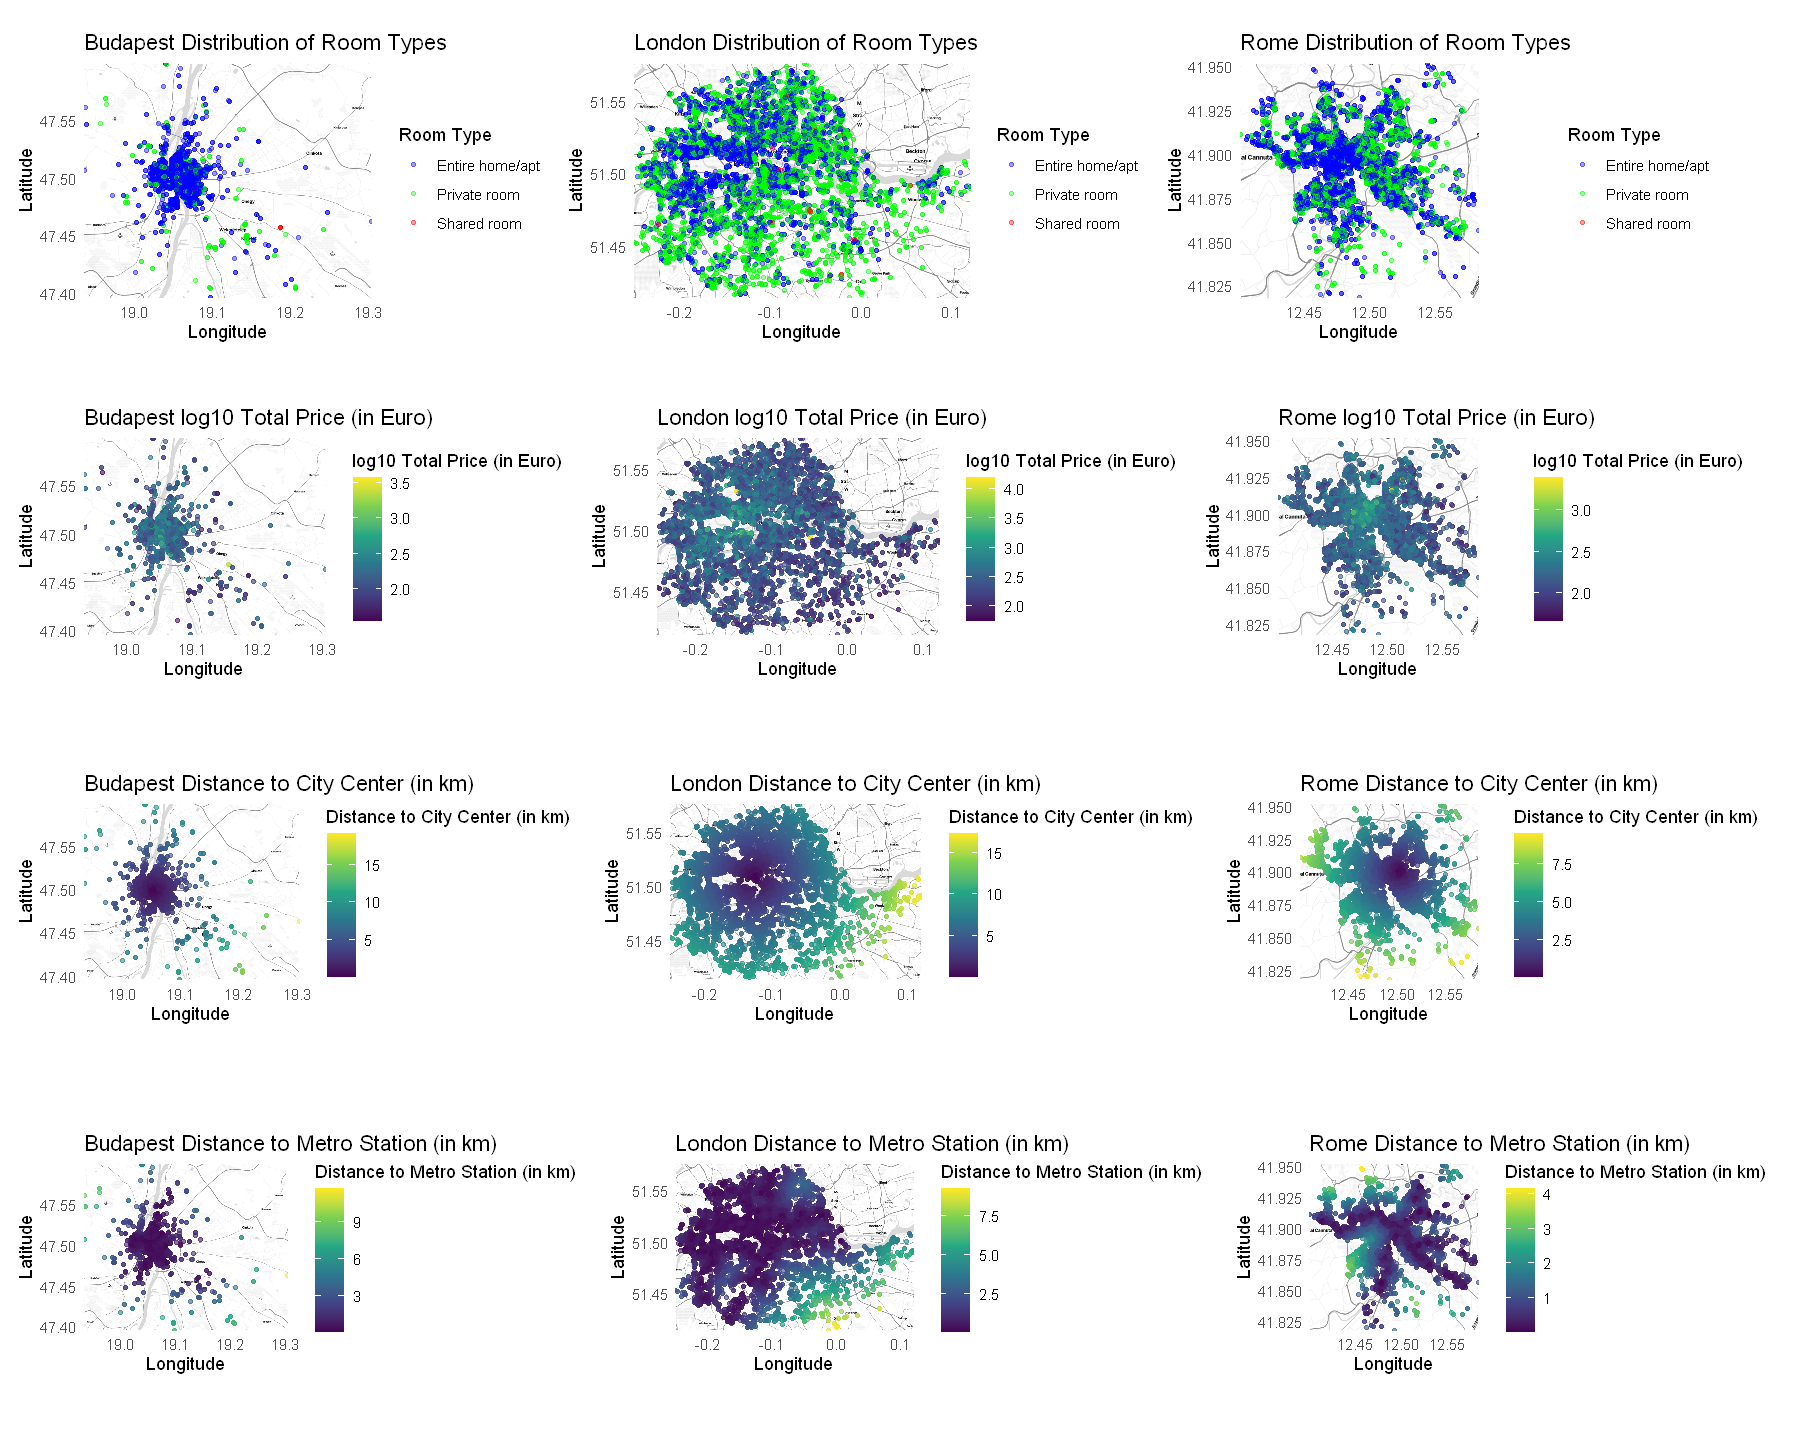

In [12]:
# Main developer: Nathan Zhang

options(repr.plot.width = 15, repr.plot.height = 12)
# Geospatial Visualization of the Budapest, London, and Rome Airbnb listings
register_stadiamaps(key = "0352871b-7427-4059-a925-dec8b550de18")

# Function to generate geospatial visualization for a city
generate_city_map <- function(city_name, airbnb_data) {
  # Get bounding box for the city
  city_bbox <- airbnb_data |>
    filter(city == city_name) |>
    summarise(
      min_lat = min(lat),
      max_lat = max(lat),
      min_lng = min(lng),
      max_lng = max(lng)
    )
     
  # Get the map for the city
  city_map_base <- get_stadiamap(
    bbox = c(
      left = city_bbox$min_lng,
      bottom = city_bbox$min_lat,
      right = city_bbox$max_lng,
      top = city_bbox$max_lat
    ),
    zoom = 12,
    maptype = "stamen_toner_lite"
  )
  
  # Filter data for the city
  city_subset <- clean_airbnb_data |>
    filter(city == city_name)
  
  # Generate the map
  city_geomap <- ggmap(city_map_base) +
    geom_point(data = city_subset, aes(x = lng, y = lat, color = room_type), alpha = 0.4, size = 1) +
    scale_color_manual(values = c("Entire home/apt" = "blue", "Private room" = "green", "Shared room" = "red")) +
    labs(title = paste0(str_to_title(city_name), " Distribution of Room Types"), x = "Longitude", y = "Latitude", color = "Room Type") +
    theme_minimal()
  
  return(list(city_geomap = city_geomap, city_map_base = city_map_base))
}

# Generate maps and map bases for Budapest, London, and Rome
budapest_map <- generate_city_map("budapest", clean_airbnb_data)
london_map <- generate_city_map("london", clean_airbnb_data)
rome_map <- generate_city_map("rome", clean_airbnb_data)


# Plot the distribution of total price on maps
make_price_map <- function(map_base, city_name) {
  ggmap(map_base) +
    geom_point(
      data  = clean_airbnb_data |> filter(city == city_name),
      aes(x = lng, y = lat, color = log10(realSum)),
      alpha = 0.6,
      size  = 1
    ) +
    scale_color_viridis_c(name = "log10 Total Price (in Euro)") +
    labs(
      title = paste0(str_to_title(city_name), " log10 Total Price (in Euro)"),
      x     = "Longitude",
      y     = "Latitude"
    ) +
    theme_minimal()
}

budapest_price_map <- make_price_map(budapest_map$city_map_base, "budapest")
london_price_map <- make_price_map(london_map$city_map_base, "london")
rome_price_map <- make_price_map(rome_map$city_map_base, "rome")

make_distance_map <- function(map_base, city_name) {
    ggmap(map_base) +
        geom_point(
        data  = clean_airbnb_data |> filter(city == city_name),
        aes(x = lng, y = lat, color = dist),
        alpha = 0.6,
        size  = 1
        ) +
        scale_color_viridis_c(name = "Distance to City Center (in km)") +
        labs(
        title = paste0(str_to_title(city_name), " Distance to City Center (in km)"),
        x     = "Longitude",
        y     = "Latitude"
        ) +
        theme_minimal()
    }

budapest_dist_map <- make_distance_map(budapest_map$city_map_base, "budapest")
london_dist_map <- make_distance_map(london_map$city_map_base, "london")
rome_dist_map <- make_distance_map(rome_map$city_map_base, "rome")

# Visualize the distance to metro stations
make_metro_map <- function(map_base, city_name) {
    ggmap(map_base) +
        geom_point(
        data  = clean_airbnb_data |> filter(city == city_name),
        aes(x = lng, y = lat, color = metro_dist),
        alpha = 0.6,
        size  = 1
        ) +
        scale_color_viridis_c(name = "Distance to Metro Station (in km)") +
        labs(
        title = paste0(str_to_title(city_name), " Distance to Metro Station (in km)"),
        x     = "Longitude",
        y     = "Latitude"
        ) +
        theme_minimal()
    }

budapest_metro_map <- make_metro_map(budapest_map$city_map_base, "budapest")
london_metro_map <- make_metro_map(london_map$city_map_base, "london")
rome_metro_map <- make_metro_map(rome_map$city_map_base, "rome")

# Combine all maps into a single plot
combined_map <- (budapest_map$city_geomap + london_map$city_geomap + rome_map$city_geomap) / 
    (budapest_price_map + london_price_map + rome_price_map) / 
    (budapest_dist_map + london_dist_map + rome_dist_map) / 
    (budapest_metro_map + london_metro_map + rome_metro_map)
    
combined_map

### Other Visualizations of `realSum`

We also create visualizations to explore the distribution of `realSum` across different cities and room types, as well as the relationship between `realSum` and other numeric variables. Note that the log10 transformation of y-axis is used in box plots for better representations of data.

`geom_smooth()` using formula = 'y ~ x'


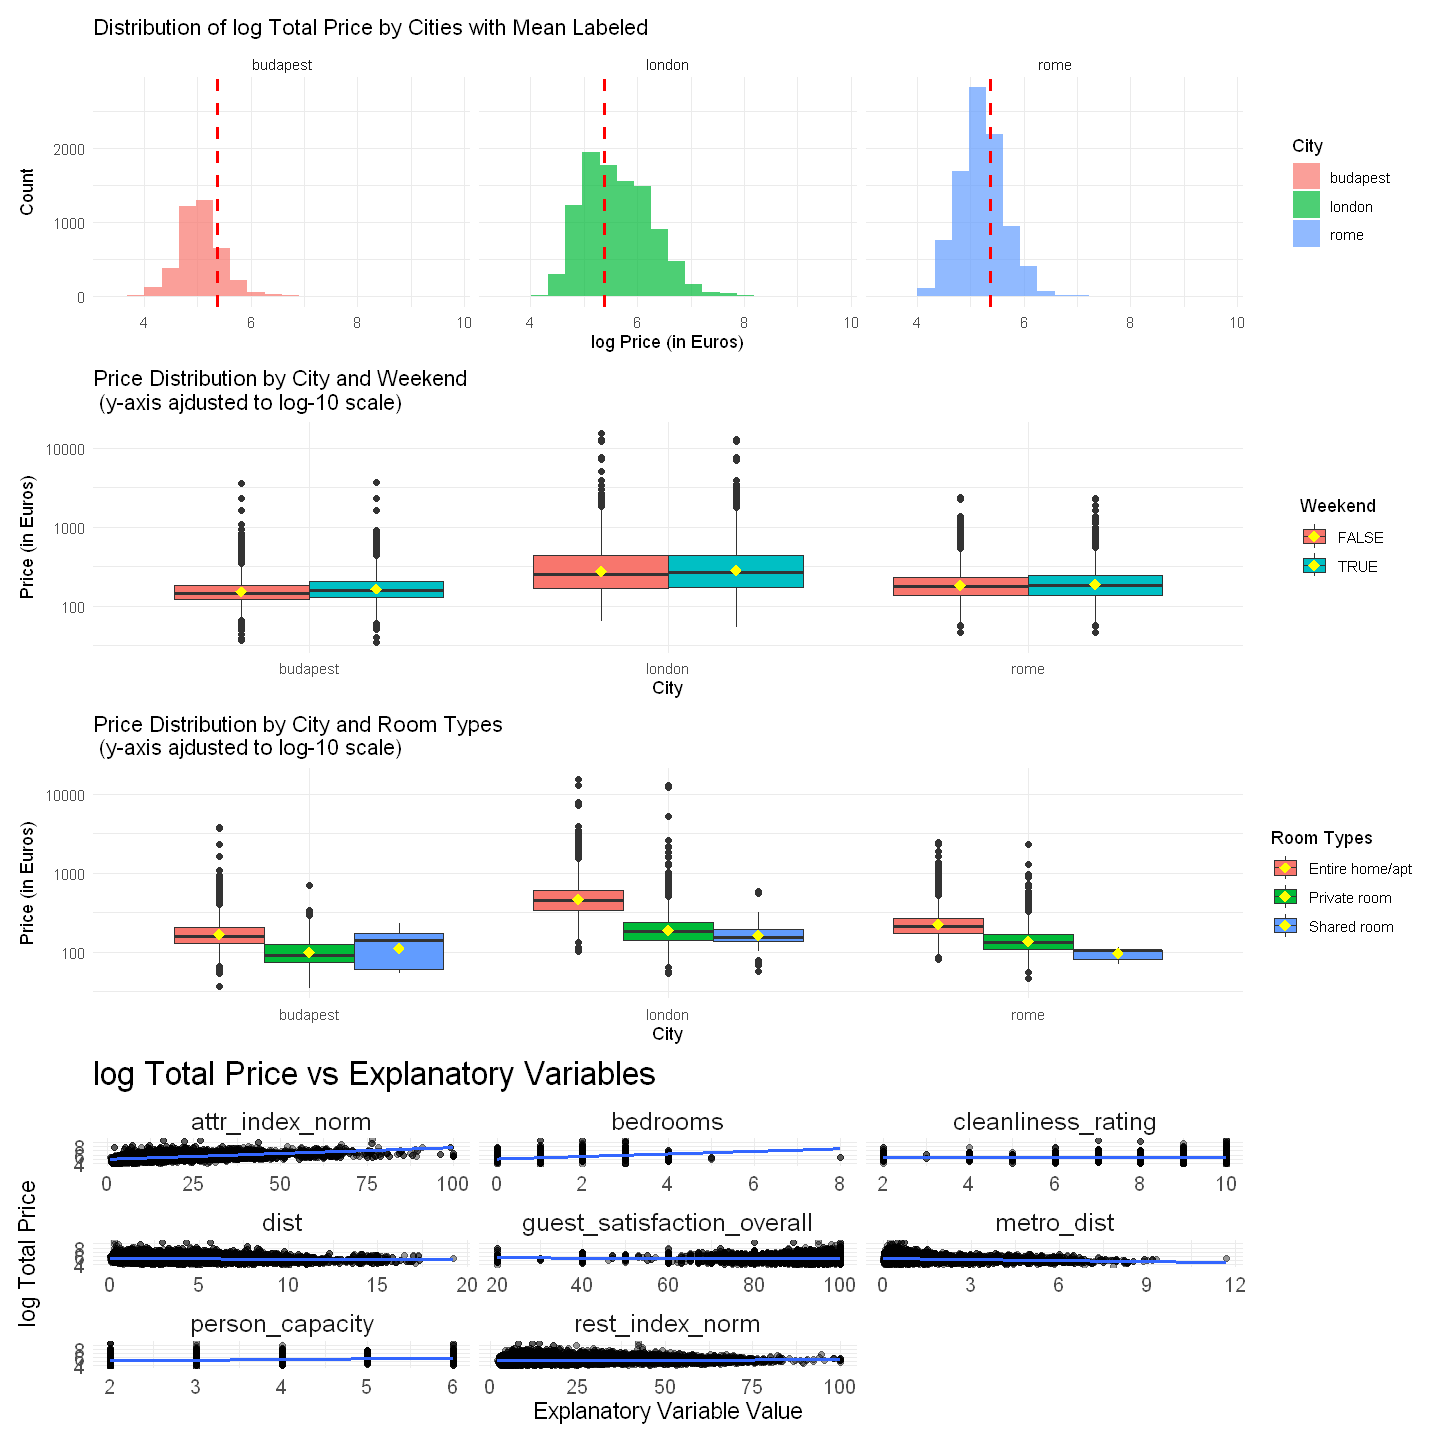

In [13]:
#Main developer: Zhihan Dong, Nathan Zhang (editted)

options(repr.plot.width=12, repr.plot.height=12)

# Visualize the log distribution of prices by cities
log_price_distribution_cities <- ggplot(clean_airbnb_data, aes(x = log(realSum), fill = city)) +
    geom_histogram(bins = 20, alpha = 0.7) +
    facet_wrap(~ city, ncol = 3) +
    geom_vline(aes(xintercept = mean(log(realSum))), color = "red", linetype = "dashed", linewidth = 1) +
    labs(title = "Distribution of log Total Price by Cities with Mean Labeled", 
    x = "log Price (in Euros)", y = "Count", fill = "City") +
    theme_minimal()

# Create box plots for price distribution by city and weekend
price_weekend_boxplot <- ggplot(clean_airbnb_data, aes(x = city, y = realSum, fill = weekend)) +
    geom_boxplot(position = position_dodge(width = 0.75)) +
    stat_summary(
        fun = mean,
        geom = "point",
        position = position_dodge(width = 0.75),
        shape = 18,    
        size = 3,
        color = "yellow",
        aes(group = weekend)
    ) +
    scale_y_log10() + 
    labs(title = "Price Distribution by City and Weekend \n (y-axis ajdusted to log-10 scale)", 
    x = "City", y = "Price (in Euros)", fill = "Weekend") +
    theme_minimal()

# Create the box plot showing the price distribution of 3 different room types
price_room_type_boxplot <- ggplot(clean_airbnb_data, aes(x = city, y = realSum, fill = room_type)) +
    geom_boxplot(position = position_dodge(width = 0.75)) +
    stat_summary(
        fun = mean,
        geom = "point",
        position = position_dodge(width = 0.75),
        shape = 18,    
        size = 3,
        color = "yellow",
        aes(group = room_type)
    ) +
    scale_y_log10() + 
    labs(title = "Price Distribution by City and Room Types \n (y-axis ajdusted to log-10 scale)", 
    x = "City", y = "Price (in Euros)", fill = "Room Types") +
    theme_minimal()

# Define the variable list for scatter plots of explanatory variables against the log(total price)
variables <- clean_airbnb_data |>
    select(where(is.numeric)) |>
    select(- realSum, -lng, -lat, -multi, -biz) |>
    colnames()

# Convert the data to long format for scatter plots
long_data <-  clean_airbnb_data|>
  mutate(log_realSum = log(realSum)) |>
  select(all_of(c(variables, "log_realSum"))) |>
  pivot_longer(cols = all_of(variables),
               names_to = "variables",
               values_to = "value")

# Create scatter plots for each explanatory variable against the total price
variables_scatter <- ggplot(long_data , aes(x = value, y = log_realSum)) +
  geom_point(alpha = 0.4) +
  facet_wrap(~ variables, scales = "free_x") + 
  labs(title = "log Total Price vs Explanatory Variables",
       x = "Explanatory Variable Value",
       y = "log Total Price") +
  geom_smooth(method = "lm", se = FALSE) +
  theme_minimal() +
  theme(plot.title = element_text(size = 20),
        strip.text = element_text(size = 15),  
        axis.title = element_text(size = 14),
        axis.text = element_text(size = 12))

# display the box plot together
log_price_distribution_cities + price_weekend_boxplot + price_room_type_boxplot +  variables_scatter + plot_layout(ncol = 1)

Such visualizations gave us the following insights:
- The log transformation of `realSum` is necessary to reduce the right skewness of the distribution, which will help improve the performance of our predictive models.
- The boxplots showed that there are indeed visually significant differences in the `realSum` across `city`, and `room_type`, which we need to account for in our models.
- After the log transformation of `realSum`, many of the numeric variables appear to be linearly correlated with it, which justifies the use of log transformation and linear regression models.

### 2.2 Analysis Plan

Based on the exploratory data analysis, we will proceed with the following analysis plan:

1. we will transform the `realSum` variable using a log transformation to reduce the right skewness of the distribution. Then, we will build a full linear regression model using `lm()` function in R with `log(realSum)` as the response variable and the other variables as predictors. 

2. For model evaluation, we will implement a 0.7/0.3 train-test split with `initial_split()` function to assess the model's performance on unseen data. We will run cross-validation on the training set to tune the model and prevent overfitting. 

3. We will use the forward selection and backward selection method to select the most significant predictors based on the Akaike Information Criterion (AIC) through `stepAIC` function.

4. we will use the `cv.glmnet()` function to perform LASSO regression for variable selection and regularization. We will use cross-validation to select the optimal lambda value that minimizes the mean squared error (MSE) of the model.

5. we will compare the results to select the best predictive model, we will also check the assumptions of linear regression, including linearity, independence, homoscedasticity, and normality of residuals. If any assumptions are violated, we will consider alternative models such as generalized linear models or non-linear regression models.

### 2.3 Results

In [14]:
# Main developer: Nathan Zhang
set.seed(555)  # For reproducible results

# Create the dataframe for final modeling
modeling_data <- clean_airbnb_data |>
    mutate(log_realSum = log(realSum)) |>
    select(-realSum, -lng, -lat)|>
    glimpse()

# Perform train-test split
data_split <- initial_split(modeling_data, prop = 0.7, strata = log_realSum)

train_data <- training(data_split)
test_data <- testing(data_split)

# View the length of the train and test sets
nrow(train_data)
nrow(test_data)

Rows: 23,042
Columns: 15
$ room_type                  <fct> Entire home/apt, Entire home/apt, Entire ho…
$ person_capacity            <dbl> 6, 6, 4, 2, 4, 4, 4, 4, 6, 4, 3, 4, 5, 6, 4…
$ host_is_superhost          <lgl> TRUE, FALSE, TRUE, FALSE, TRUE, FALSE, FALS…
$ multi                      <dbl> 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0…
$ biz                        <dbl> 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1…
$ cleanliness_rating         <dbl> 10, 9, 10, 9, 10, 9, 6, 9, 10, 10, 10, 10, …
$ guest_satisfaction_overall <dbl> 99, 98, 98, 92, 99, 91, 80, 92, 88, 96, 100…
$ bedrooms                   <dbl> 1, 2, 1, 1, 2, 2, 2, 1, 2, 1, 0, 1, 2, 2, 0…
$ dist                       <dbl> 0.3593550, 0.9294272, 2.4508403, 1.5594494,…
$ metro_dist                 <dbl> 0.3526430, 0.2002355, 0.2794518, 0.4779711,…
$ attr_index_norm            <dbl> 24.116552, 100.000000, 9.755551, 11.433155,…
$ rest_index_norm            <dbl> 67.656853, 34.267700, 14.538245, 24.702048,…
$ city         

[1] 16127

[1] 6915

#### Model Training and Evaluation

In [15]:
# Main developer: Nathan Zhang

folds <- createFolds(train_data[["log_realSum"]], k = 10, list = TRUE, returnTrain = FALSE)

# Initialize storage
results <- data.frame(
  fold           = seq_along(folds),
  rmse_backward  = NA_real_,
  rmse_forward = NA_real_,
  rmse_lasso     = NA_real_
)

In [16]:
# Main developer: Nathan Zhang

# Define the training loop for cross-validation
for(i in seq_along(folds)) {
    test_idx  <- folds[[i]]
    train_idx <- setdiff(seq_len(nrow(train_data)), test_idx)
    train_df  <- train_data[train_idx, ]
    test_df   <- train_data[test_idx, ]

    # Define the full model
    full_model <- lm(log_realSum ~ ., data = train_df)

    # Define the null model
    null_model <- lm(log_realSum ~ 1, data = train_df)

    # Perform forward selection
    n <- nrow(train_df)
    forward_sel <- stepAIC(null_model, scope = list(lower = null_model, upper = full_model), direction = "forward", k = log(n))

    # Get the summary of the forward selection model
    forward_summary <- summary(forward_sel)

    # Perform backward selection
    backward_sel <- stepAIC(full_model, direction = "backward", k = log(n))

    # Get the summary of the backward selection model
    backward_summary <- summary(backward_sel)

    # Prepare the data for LASSO regression
    x_train <- model.matrix(log_realSum ~ ., data = train_df)[ , -1 ] 
    y_train <- train_df$log_realSum

    # Perform LASSO regression with cross-validation
    lasso_model <- cv.glmnet(
    x = x_train,
    y = y_train,
    nfolds = 10,
    alpha = 1)

    # Get the model with the best lambda
    best_lambda <- lasso_model$lambda.min
    lasso_best_model <- glmnet(
        x = x_train,
        y = y_train,
        alpha = 1,
        lambda = best_lambda
    )

    # Make predictions on the test set
    pred_lasso <- predict(lasso_best_model, newx = model.matrix(log_realSum ~ ., data = test_df)[ , -1 ])
    

    pred_for <- predict(forward_sel, newdata = test_df)
    pred_back <- predict(backward_sel, newdata = test_df)
    results$rmse_forward[i] <- rmse(test_df$log_realSum, pred_for)
    results$rmse_backward[i] <- rmse(test_df$log_realSum, pred_back)
    results$rmse_lasso[i] <- rmse(test_df$log_realSum, pred_lasso)
}


Start:  AIC=-15484.89
log_realSum ~ 1

                             Df Sum of Sq    RSS    AIC
+ attr_index_norm             1   1279.58 3711.0 -19775
+ city                        2    833.03 4157.6 -18116
+ room_type                   2    796.20 4194.4 -17988
+ person_capacity             1    742.46 4248.2 -17813
+ bedrooms                    1    506.26 4484.4 -17028
+ biz                         1    106.69 4883.9 -15789
+ metro_dist                  1     89.94 4900.7 -15739
+ multi                       1     65.56 4925.1 -15667
+ host_is_superhost           1     32.03 4958.6 -15569
+ guest_satisfaction_overall  1     15.89 4974.7 -15522
+ weekend                     1     12.61 4978.0 -15512
+ dist                        1     11.79 4978.8 -15510
+ cleanliness_rating          1      3.67 4986.9 -15486
<none>                                    4990.6 -15485
+ rest_index_norm             1      1.04 4989.6 -15478

Step:  AIC=-19775.06
log_realSum ~ attr_index_norm

            

In [17]:
# Main developer: Nathan Zhang

# Summarize the results for backward selection
results_summary <- results |>
    select(-fold) |>
    summary()

results_summary

# Print the mean RMSE for each model
cat("Mean RMSE for backward selection model:", mean(results$rmse_backward), "\n")
cat("Mean RMSE for forward selection model:", mean(results$rmse_forward), "\n")
cat("Mean RMSE for LASSO model:", mean(results$rmse_lasso), "\n")

 rmse_backward     rmse_forward      rmse_lasso    
 Min.   :0.3418   Min.   :0.3418   Min.   :0.3419  
 1st Qu.:0.3456   1st Qu.:0.3456   1st Qu.:0.3457  
 Median :0.3561   Median :0.3561   Median :0.3562  
 Mean   :0.3564   Mean   :0.3564   Mean   :0.3564  
 3rd Qu.:0.3661   3rd Qu.:0.3661   3rd Qu.:0.3660  
 Max.   :0.3758   Max.   :0.3758   Max.   :0.3758  

Mean RMSE for backward selection model: 0.3564357 
Mean RMSE for forward selection model: 0.3564357 
Mean RMSE for LASSO model: 0.3564454 


In [18]:
# Main developer: Nathan Zhang

# t-test for comparing the RMSE of backward/forward selection and LASSO regression
t_test_backward_forward <- t.test(results$rmse_backward, results$rmse_forward, paired = TRUE)
t_test_backward_lasso <- t.test(results$rmse_backward, results$rmse_lasso, paired = TRUE)
t_test_forward_lasso <- t.test(results$rmse_forward, results$rmse_lasso, paired = TRUE)

# Display the t-test results
t_test_backward_forward
t_test_backward_lasso
t_test_forward_lasso


	Paired t-test

data:  results$rmse_backward and results$rmse_forward
t = 1.0445, df = 9, p-value = 0.3235
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -6.535821e-16  1.774907e-15
sample estimates:
mean difference 
   5.606626e-16 



	Paired t-test

data:  results$rmse_backward and results$rmse_lasso
t = -0.30529, df = 9, p-value = 0.7671
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -8.126479e-05  6.193845e-05
sample estimates:
mean difference 
   -9.66317e-06 



	Paired t-test

data:  results$rmse_forward and results$rmse_lasso
t = -0.30529, df = 9, p-value = 0.7671
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -8.126479e-05  6.193845e-05
sample estimates:
mean difference 
   -9.66317e-06 


In [19]:
# Main developer: Nathan Zhang

# Fit the backward selection model on the full training data
backward_model <- stepAIC(lm(log_realSum ~ ., data = train_data), direction = "backward", k = log(nrow(train_data)))
pred_backward <- predict(backward_model, newdata = test_data)


Start:  AIC=-33130.29
log_realSum ~ room_type + person_capacity + host_is_superhost + 
    multi + biz + cleanliness_rating + guest_satisfaction_overall + 
    bedrooms + dist + metro_dist + attr_index_norm + rest_index_norm + 
    city + weekend

                             Df Sum of Sq    RSS    AIC
- host_is_superhost           1      0.12 2046.2 -33139
- guest_satisfaction_overall  1      0.25 2046.4 -33138
<none>                                    2046.1 -33130
- multi                       1      4.15 2050.3 -33107
- weekend                     1      4.66 2050.8 -33103
- dist                        1      5.47 2051.6 -33097
- cleanliness_rating          1      6.44 2052.6 -33089
- metro_dist                  1      6.62 2052.7 -33088
- rest_index_norm             1      7.49 2053.6 -33081
- biz                         1      8.04 2054.2 -33077
- person_capacity             1     67.58 2113.7 -32616
- attr_index_norm             1     81.97 2128.1 -32506
- bedrooms              

In [20]:
# Main developer: Nathan Zhang

# Calculate RMSE for the backward selection model
rmse_backward <- rmse(test_data$log_realSum, pred_backward)

cat("test RMSE for the backward selection model:", rmse_backward, "\n")

test RMSE for the backward selection model: 0.3576098 


#### Assumptions Check

`geom_smooth()` using formula = 'y ~ x'


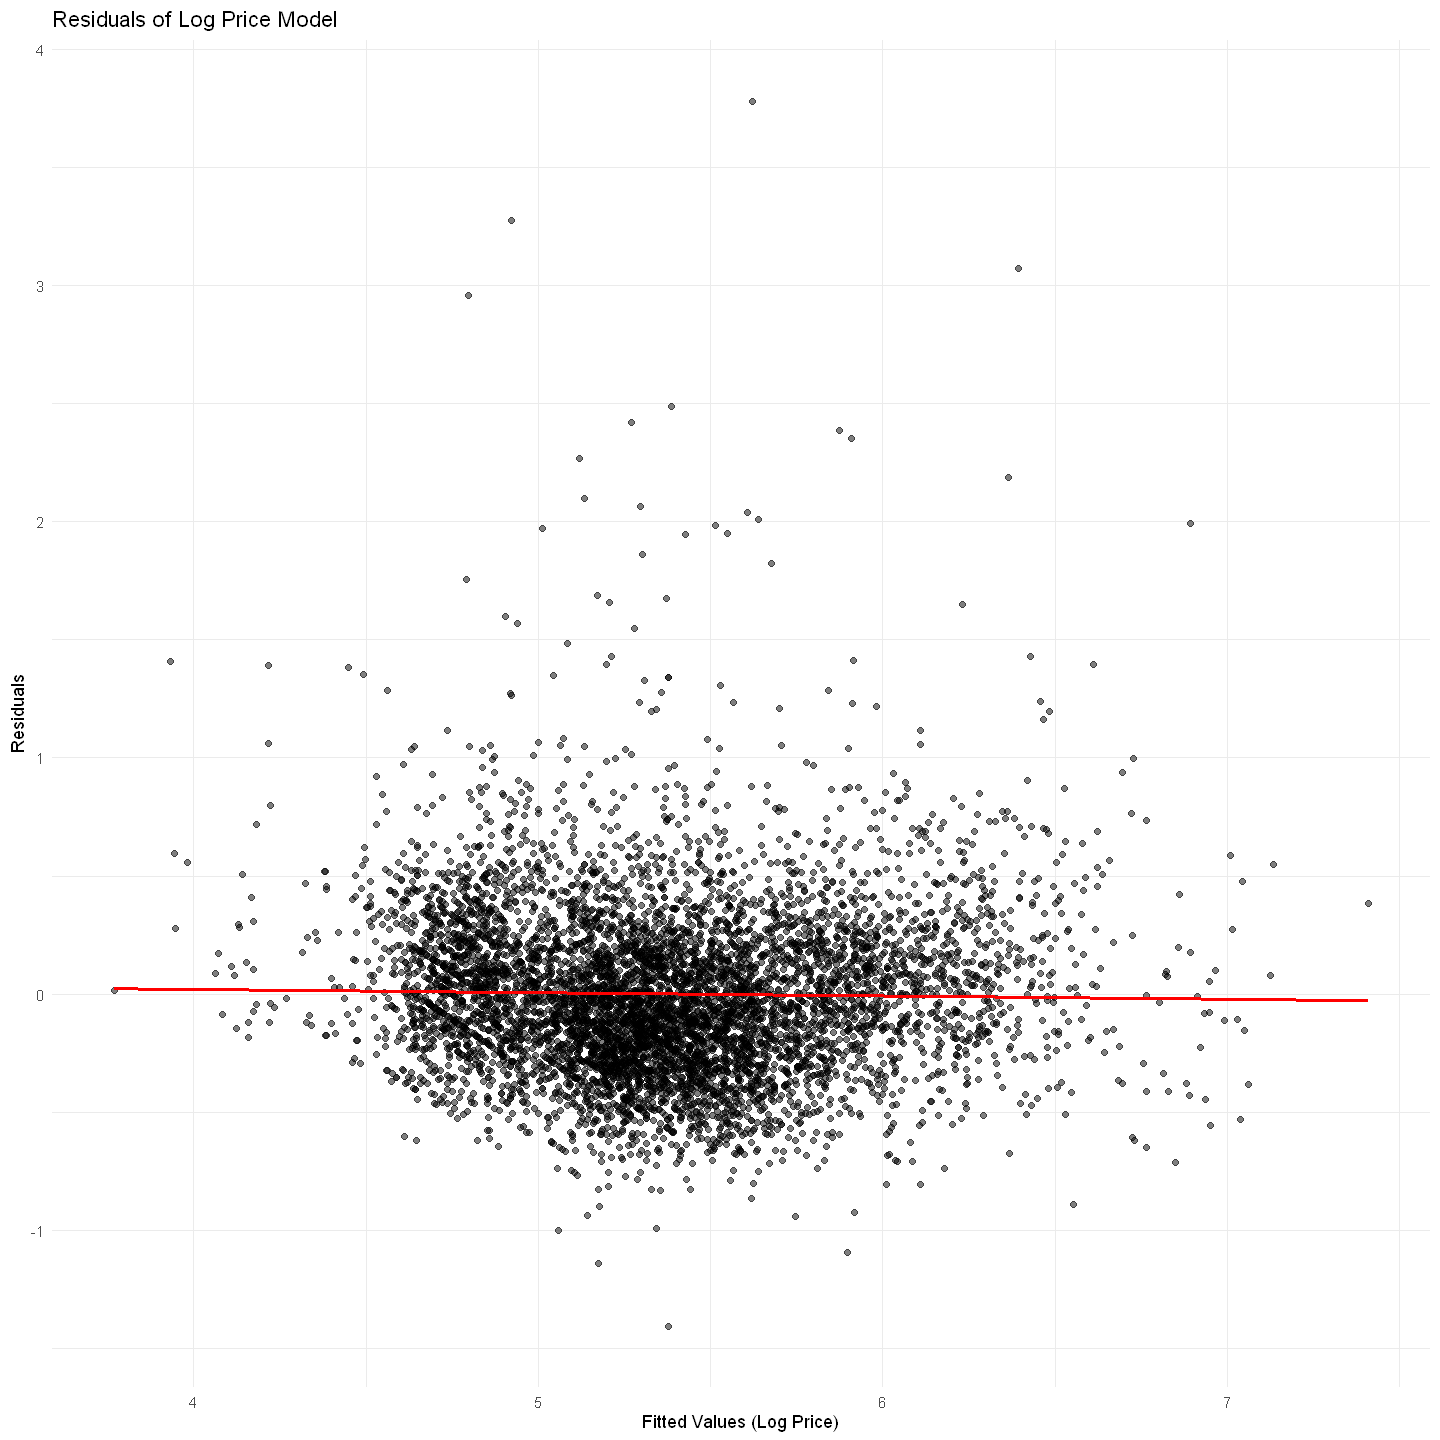

In [21]:
# Main developer: Nathan Zhang

# Plot the residuals of the backward selection model
bwd_residuals_plot <- ggplot(data = tibble(
    fitted = pred_backward,
    resid = test_data$log_realSum - pred_backward),
    aes(x = fitted, y = resid)
 ) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = "lm", color = "red", se = FALSE) +
    labs(title = "Residuals of Log Price Model",
         x = "Fitted Values (Log Price)",
         y = "Residuals") +
    theme_minimal()

bwd_residuals_plot

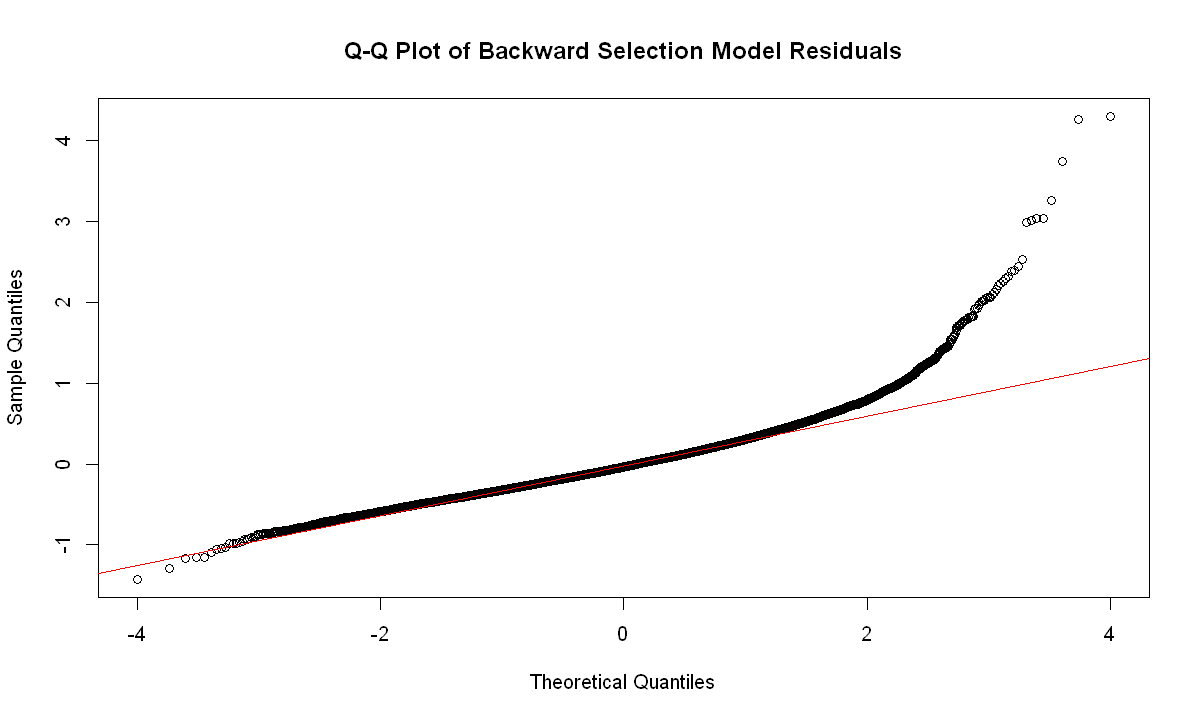

In [22]:
# Main developer: Nathan Zhang

options(repr.plot.width = 10, repr.plot.height = 6)

# Check the normality of residuals using Q-Q plot
qqnorm(residuals(backward_model), main = "Q-Q Plot of Backward Selection Model Residuals")
qqline(residuals(backward_model), col = "red")


In [23]:
# Main developer: Nathan Zhang

# Add fitted values and their square to the training data
train_data <- train_data |>
    mutate(
        fitted_values = fitted(backward_model),
        fitted_values_sq = fitted_values^2
    )

# Perform White's test for heteroscedasticity
white_test_backward <- bptest(backward_model, ~ fitted_values + fitted_values_sq, data = train_data)

white_test_backward


	studentized Breusch-Pagan test

data:  backward_model
BP = 68.681, df = 2, p-value = 1.219e-15


In [24]:
# Main developer: Nathan Zhang

# Test the multicollinearity of the backward selection model using VIF
vif_backward <- vif(backward_model)

vif_backward

,GVIF,Df,GVIF^(1/(2*Df))
room_type,1.668972,2,1.136612
person_capacity,2.164935,1,1.471372
multi,1.432141,1,1.196721
biz,1.547943,1,1.244163
cleanliness_rating,1.055149,1,1.027204
bedrooms,1.564632,1,1.250852
dist,4.501773,1,2.121738
metro_dist,1.894605,1,1.376446
attr_index_norm,3.234462,1,1.798461
rest_index_norm,2.774955,1,1.665820


## 3. Discussion

## 4. References